<a href="https://colab.research.google.com/github/tinode89/Analyse_donn-es_criminelles-/blob/main/tinode89/Analyse_finan_fbk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files
uploaded = files.upload()

Saving facebook.csv to facebook.csv


In [ ]:
fb = pd.read_csv(io.BytesIO(uploaded['facebook.csv']))
fb.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-12-31,20.400000,20.510000,19.990000,20.049999,19.459270,4157500
1,2015-01-02,20.129999,20.280001,19.809999,20.129999,19.536913,2842000
2,2015-01-05,20.129999,20.190001,19.700001,19.790001,19.206934,4948800
3,2015-01-06,19.820000,19.840000,19.170000,19.190001,18.624611,4944100
4,2015-01-07,19.330000,19.500000,19.080000,19.139999,18.576082,8045200


In [ ]:
fb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       780 non-null    object 
 1   Open       780 non-null    float64
 2   High       780 non-null    float64
 3   Low        780 non-null    float64
 4   Close      780 non-null    float64
 5   Adj Close  780 non-null    float64
 6   Volume     780 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 42.8+ KB


In [ ]:
fb.describe()

,Open,High,Low,Close,Adj Close,Volume
count,780.000000,780.000000,780.000000,780.000000,780.000000,7.800000e+02
mean,80.212705,81.285654,79.022397,80.264897,79.914215,1.204453e+07
std,64.226121,65.048907,63.190963,64.198375,64.327846,8.221848e+06
min,19.250000,19.500000,18.940001,19.139999,18.576082,1.311200e+06
25%,25.525000,26.085000,24.845000,25.475000,25.134512,7.215200e+06
50%,53.379999,54.034999,52.930000,53.420000,53.035403,9.728700e+06
75%,113.322502,115.779999,110.297499,113.702501,113.261238,1.408885e+07
max,245.770004,249.270004,244.449997,246.850006,246.850006,9.232320e+07


In [ ]:
fb.shape

(780, 7)

In [ ]:
fb.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
fb = fb.set_index('Date')
fb.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,20.400000,20.510000,19.990000,20.049999,19.459270,4157500
2015-01-02,20.129999,20.280001,19.809999,20.129999,19.536913,2842000
2015-01-05,20.129999,20.190001,19.700001,19.790001,19.206934,4948800
2015-01-06,19.820000,19.840000,19.170000,19.190001,18.624611,4944100
2015-01-07,19.330000,19.500000,19.080000,19.139999,18.576082,8045200


Axes(0.125,0.11;0.775x0.77)


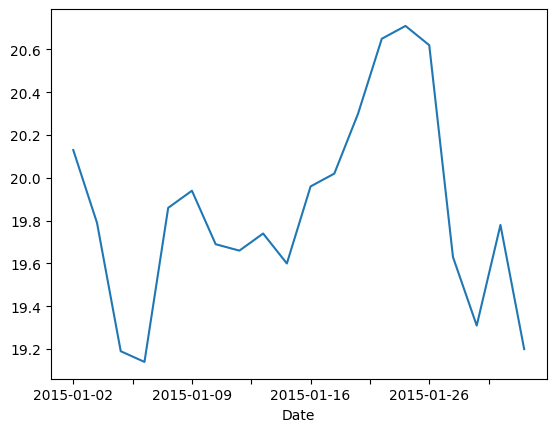

In [ ]:
print(fb.loc['2015-01-01':'2015-01-31', 'Close'].plot())

## 1. Fusionner les données sur les actions et ajouter deux colonnes - MA10 et MA50

In [ ]:
#fb['MA10'] = fb['Close'].rolling(10).mean()
#fb['MA50'] = fb['Close'].rolling(50).mean()
fb.head()
fb.dropna(inplace=True)
fb.head()

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50
Date,,,,,,,,
2015-03-13,22.559999,22.760000,22.250000,22.700001,22.116024,8982200,22.648,21.0174
2015-03-16,22.879999,23.110001,22.730000,22.969999,22.379078,5923900,22.685,21.0758
2015-03-17,22.920000,23.260000,22.760000,23.250000,22.651876,7497500,22.792,21.1382
2015-03-18,23.250000,23.370001,22.660000,22.870001,22.281652,10337600,22.836,21.1998
2015-03-19,22.950001,23.299999,22.780001,23.219999,22.622650,7768900,22.872,21.2804


## 2. Ajoutons la colonne « Actions » pour prendre des décisions basées sur la stratégie

In [ ]:
#Ajout d'une nouvelle colonne « Actions », si MA10>MA50, indiquer Bye (achat d'une action), sinon, indiquer Nothing (ne rien faire)
fb['Actions'] = ['Bye' if fb.loc[ei, 'MA10']>fb.loc[ei, 'MA50'] else 'Nothing' for ei in fb.index]
fb.head()

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50,Actions
Date,,,,,,,,,
2015-03-13,22.559999,22.760000,22.250000,22.700001,22.116024,8982200,22.648,21.0174,Bye
2015-03-16,22.879999,23.110001,22.730000,22.969999,22.379078,5923900,22.685,21.0758,Bye
2015-03-17,22.920000,23.260000,22.760000,23.250000,22.651876,7497500,22.792,21.1382,Bye
2015-03-18,23.250000,23.370001,22.660000,22.870001,22.281652,10337600,22.836,21.1998,Bye
2015-03-19,22.950001,23.299999,22.780001,23.219999,22.622650,7768900,22.872,21.2804,Bye


In [ ]:
##Ajouter une nouvelle colonne « Profit » en utilisant List Comprehension, pour toute ligne dans fb, si Actions=Bye, le profit est calculé comme le prix de clôture de demain - le prix de clôture d'aujourd'hui. Sinon, le bénéfice est de 0.
fb['Close1'] = fb['Close'].shift(-1)
fb['Profit'] = [fb.loc[ei, 'Close1']-fb.loc[ei, 'Close'] if fb.loc[ei, 'Actions']=='Bye' else 0 for ei in fb.index]
fb.head(20)

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50,Actions,Close1,Profit
Date,,,,,,,,,,,
2015-03-13,22.559999,22.760000,22.250000,22.700001,22.116024,8982200,22.648000,21.0174,Bye,22.969999,0.269998
2015-03-16,22.879999,23.110001,22.730000,22.969999,22.379078,5923900,22.685000,21.0758,Bye,23.250000,0.280001
2015-03-17,22.920000,23.260000,22.760000,23.250000,22.651876,7497500,22.792000,21.1382,Bye,22.870001,-0.379999
2015-03-18,23.250000,23.370001,22.660000,22.870001,22.281652,10337600,22.836000,21.1998,Bye,23.219999,0.349998
2015-03-19,22.950001,23.299999,22.780001,23.219999,22.622650,7768900,22.872000,21.2804,Bye,23.469999,0.250000
2015-03-20,23.410000,23.610001,23.190001,23.469999,22.866215,11552100,22.964000,21.3670,Bye,22.709999,-0.760000
2015-03-23,22.770000,23.070000,22.700001,22.709999,22.125767,10595700,22.974000,21.4240,Bye,22.400000,-0.309999
2015-03-24,22.639999,22.799999,22.299999,22.400000,21.823744,8262000,22.914000,21.4732,Bye,21.040001,-1.359999
2015-03-25,22.389999,22.389999,20.969999,21.040001,20.498730,13563800,22.730000,21.5002,Bye,20.969999,-0.070002


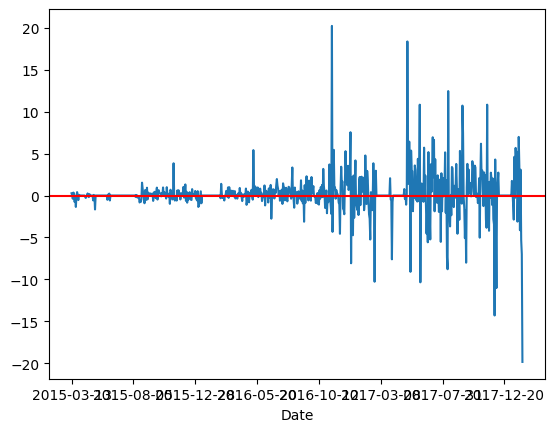

In [ ]:
###Tracons un graphique pour montrer le bénéfice/la perte.
fb['Profit'].plot()
plt.axhline(y=0, color='r', linestyle='-')

## 3. Utiliser .cumsum() pour afficher la performance de notre modèle si nous suivons la stratégie

In [ ]:
##Utilisons .cumsum() pour calculer la richesse accumulée sur la période.
fb['Richesse'] = fb['Profit'].cumsum()
fb.head()

,Open,High,Low,Close,Adj Close,Volume,MA10,MA50,Actions,Close1,Profit,Richesse
Date,,,,,,,,,,,,
2015-03-13,22.559999,22.760000,22.250000,22.700001,22.116024,8982200,22.648,21.0174,Bye,22.969999,0.269998,0.269998
2015-03-16,22.879999,23.110001,22.730000,22.969999,22.379078,5923900,22.685,21.0758,Bye,23.250000,0.280001,0.549999
2015-03-17,22.920000,23.260000,22.760000,23.250000,22.651876,7497500,22.792,21.1382,Bye,22.870001,-0.379999,0.170000
2015-03-18,23.250000,23.370001,22.660000,22.870001,22.281652,10337600,22.836,21.1998,Bye,23.219999,0.349998,0.519998
2015-03-19,22.950001,23.299999,22.780001,23.219999,22.622650,7768900,22.872,21.2804,Bye,23.469999,0.250000,0.769998


Text(0.5, 1.0, 'Richesse')

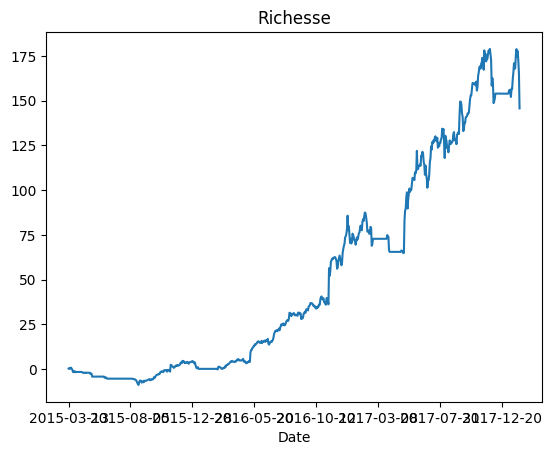

In [ ]:
#Tracons la richesse pour montrer la croissance du profit sur la période
fb['Richesse'].plot()
plt.title('Richesse')